In [31]:
import matplotlib.pyplot as plt  #risanje grafov
import numpy as np  #numerične metode

import colors
import handcalcs.render  #izpis izpeljav

def graf(v=5, s=5):
    '''
        Funkcija pripravi graf in nastavi koordinatne osi 
    '''
    fig, ax = plt.subplots(figsize=(s,v))
    ax.set_prop_cycle(color=colors.Texas)
    ax.set_xlabel('x', loc='right')
    ax.set_ylabel('y', loc='top')
    ax.spines[['left', 'bottom']].set_position('zero')
    ax.spines[['top', 'right']].set_visible(False);
    ax.axis('equal') 
    return ax

## Odvod - numerično odvajanje

Odvajanje in integriranje sta temeljna postopka matematične analize in ju pogosto uporabljamo v naravoslovku in tehniki, kakor tudi na številnih drugih področjih. V matematiki poostopka obravnavamo simbolno. Uporabljamo pravila za odvajanje, integracijske tehnike in analitične metode. V programskem jeziku Python pa lahko ta postopka izvajamo tako simbolno, kot v matematiki, pa tudi numerično, saj je obdelava velikega števila računskih operacij z računalnikom preprosta in hitra.

V nadaljevanju tega poglavja se bomo posvetili numeričnemu pristopu. Analitični pristop pa je razložen v poglavju _[Simbolično računanje s knjižnico SymPy]()_. 

Numerični pristop temelji na približkih. Knjižnici NumPy in SciPy omogočata izračun odvodov in integralov z uporabo diskretnih podatkov in algoritmov, kot so trapezna metoda, Simpsonovo pravilo ali numerično odvajanje. Izvajanje omenjenih metod brez računalnika je v praksi zamudno. Vendar je tak pristop nujen, kadar delamo z realnimi podatki, merjenji ali funkcijami, ki jih ne moremo odvajati ali integrirati simbolno.


### Znana in neznana funkcija

Vrednosti odvoda funkcije lahko izračunamo numerično, kadar poznamo funkcijski predpis in za nabor vrednosti iz definicijskega območja lahko izračunamo funkcijske vrednosti primitivne funkcije. Prav tako pa lahko vrednosti odvodov izračunamo tudi, kadar funkcijskega predpisa ne poznamo, vendar za nekatere vrednosti iz definicijskega območja vseeno poznamo funkcijske vrednosti. Praktičen primer slednjega so izmerjene vrednosti. 

Oba pristopa si poglejmo na primeru funkcije:

$f(x) = \dfrac{(x+4)}{\sqrt{(x^2+1)}}$

Predpostavimo najprej, da tega funkcijskega predpisa ne poznamo, vendar poznamo funkcijske vrednosti v določenih točkah. Morda smo za določene vrednosti neodvisne spremenljivke eksperimentalno izmerili vrednosti odvisne spremenljivke. V našem primeru smo seveda podatke umetno ustvarili tako, da smo zgornjo funkcijo uporabili, da smo izračunali funkcijske vrednosti za vsako celo vrednost $x$ med -10 in 10. Vrednosti neodvisne spremenljivke zapišimo v seznam `x`. Funkcijske vrednosti za vsak `x` prav tako zapišimo v seznam, in sicer seznam `y`. 


In [58]:
#zapišemo funkcijo, uporabili jo bomo za oba primera
def f(x):
    return (x+4)/(x**2+1)**(1/2)


### Izmerjene vrednosti
Ustvarimo cela števila med -10 in 10 ter izračunamo funkcijske vrednosti. Predpostavimo, da smo te podatke pridobili iz meritev.


In [33]:
x = np.linspace(-10, 10, 21)
y = f(x)
x,y

(array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
          1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.]),
 array([-0.59702231, -0.55215763, -0.49613894, -0.42426407, -0.32879797,
        -0.19611614,  0.        ,  0.31622777,  0.89442719,  2.12132034,
         4.        ,  3.53553391,  2.68328157,  2.21359436,  1.940285  ,
         1.76504522,  1.64398987,  1.55563492,  1.48841682,  1.43560984,
         1.39305207]))

Podatke imamo pripravljene.
```
x = [-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
          1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.]

y = [-0.59702231, -0.55215763, -0.49613894, -0.42426407, -0.32879797,
        -0.19611614,  0.        ,  0.31622777,  0.89442719,  2.12132034,
         4.        ,  3.53553391,  2.68328157,  2.21359436,  1.940285  ,
         1.76504522,  1.64398987,  1.55563492,  1.48841682,  1.43560984,
         1.39305207]
```        

Prikažimo vrednosti v grafu.

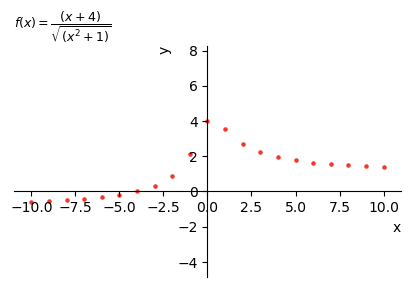

In [34]:
ax = graf(v=3)
ax.set_title('$f(x) = \dfrac{(x+4)}{\sqrt{(x^2+1)}}$', loc='left', fontsize=9);
ax.scatter(x, y, s=5);


Izračunamo vrednosti odvodov funkcije $f$ v vseh točkah, kjer poznamo funkcijsko vrednost.

Za izračun uporabimo funkcijo `gradient` iz knjižnice `numpy`. 


In [35]:
y_prime = np.gradient(y, x[1]-x[0]) 

In [36]:
y_prime

array([ 0.04486468,  0.05044169,  0.06394678,  0.08367048,  0.11407397,
        0.16439899,  0.25617195,  0.4472136 ,  0.90254629,  1.5527864 ,
        0.70710678, -0.65835921, -0.66096977, -0.37149829, -0.22427457,
       -0.14814756, -0.10470515, -0.07778653, -0.06001254, -0.04768237,
       -0.04255777])

Prvi parameter funkcije `gradient` je nabor funkcijskih vrednosti funkcije $f(x)$. 

Drugi parameter določa razmik med $x$ vrednostmi. Privzeta vrednost razmika med vsemi zaporednimi vrednostmi $x$ je 1, kar za naš primer velja. Vrednosti v seznamu namreč tečejo med -10 in 10 z razmikom 1. Tako v našem primeru drugega parametra niti ni bilo potrebno določiti. 

Če je razmik med $x$ različen od 1, je nujno določiti tretji parameter, sicer vrednosti odvodov ne bodo izračunane pravilno (glej razdelek [Razmik med vrednostmi](#Razmik-med-vrednostmi)). Lahko se tudi zgodi, da razmiki med posameznimi $x$ niso konstantni. V tem primeru namesto ene vrednosti kot drugi parameter podamo seznam vseh razmikov med $x$. 

V grafu prikažemo vrednosti primitivne funkcije in odvodov v točkah `x`.

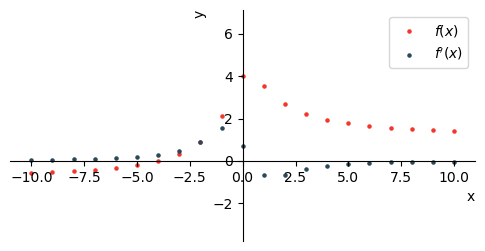

In [40]:
ax = graf(s=6, v=3)
#ax.set_title('$f^\prime$', loc='left');

ax.scatter(x, y, s=5, label='$f(x)$')
ax.scatter(x, y_prime, s=5, label='$f^\prime(x)$');
ax.legend();

Na grafu vidimo, da so temnejše točke blizu horizontalne osi tam, kjer je višina med sosednjima svetlima točkama zelo podobna. Če se torej $f(x)$ spreminja počasi, je odvod funkcije okoli vrednosti 0, kar seveda tudi pričakujemo.  

### Poznana funkcija

V tem razdelku bomo upoštevali, da funkcijski predpis poznamo. V tem primeru lahko seveda izračunamo funkcijske vrednosti za poljubno vrednost iz definicijskega območja funkcije. 

Najprej bomo pripravili seznam vseh vrednosti $x$, kjer želimo izračunati $f(x)$. Za vse izračunane funkcijske vrednosti lahko izračunamo $f^\prime(x)$ na enak način kot v predhodnem primeru.

In [42]:
x = np.linspace(-10, 10, 1000)  # na interval postavimo 1000 vrednosti x 
y = f(x)

y_prime = np.gradient(y, x[1]-x[0]) 

Funkcijo in njen odvod sedaj lahko tudi narišemo.

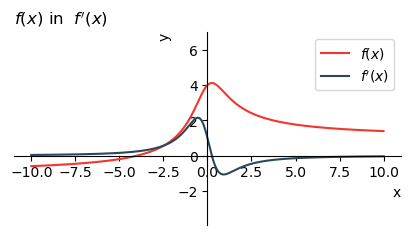

In [49]:
ax = graf(v=2.5)
ax.set_title('$f(x)$ in  $f^\prime(x)$', loc='left');

#prikažemo vrednosti
ax.plot(x, y, label='$f(x)$');
ax.plot(x, y_prime, label='$f^\prime(x)$')
ax.legend();

### Razmik med vrednostmi

Poglejmo si še pomen drugega parametra funkcije za odvajanje `gradient()`.

Podana je funkcija:

$f(x) = \sqrt{\sin{x}}$

Izračunaj odvod funkcije $f^\prime(x)$ in nariši potek odvoda. 

Za numerični izračun odvoda bomo potrebovali funkcijske vrednosti $f(x)$ za izbrani nabor vrednosti $x$. Iz funkcijskega predpisa lahko vidimo, da funkcija ni realna za vsak $x$. Zato bomo za računanje odvoda uporabili samo nabor $x$, ki vrača realne vrednosti. V našem primeru bomo opazovali funkcijske vrednosti na intervalu [0, $\pi$].


In [51]:
x = np.linspace(0, np.pi, 180)

Interval smo razdelili na 180 delov tako, da je med posameznimi zaporednimi vrednostmi $x$ vedno enaka razdalja. Vendar pa ta razdalja NI enaka 1!  

Sedaj izračunajmo funkcijske vrednosti za vsak $x$.

In [52]:
y = np.sqrt(np.sin(x))

Iz funkcijskih vrednosti izračunamo vrednosti odvodov v istih točkah. Odvoda bomo izračunali dvakrat, in sicer najprej tako, da bomo pustili privzeto vrednost razmika med $x$ (kar znaša 1). Nato bomo izračunali še enkrat, tako da bomo upoštevali dejanski razmik med $x$.

In [53]:
y_prime = np.gradient(y)  # napačne vrednosti, ker upošteva razdalje med točkami po x osi 1
y_prime_c = np.gradient(y, x[1]-x[0])  #korekcija razdalje med točkami po x osi

V grafu prikažemo vrednosti odvodov za oba primera.

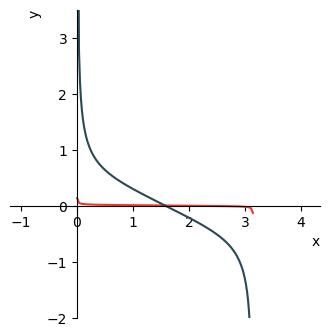

In [57]:
ax = graf(s=4, v=4)
ax.set_ylim(-2, 3.5)
ax.plot(x, y_prime)
ax.plot(x, y_prime_c);

Vidimo, da se vrednosti obeh odvodov pomembno razlikujejo. Pri izračunu odvoda s funkcijo `gradient` moramo vedno biti pozorni tudi na vrednosti $x$ iz katerih smo izračunali funkcijske vrednosti. V izogib takšnim napakam lahko razdaljo med $x_i$ in $x_{i+1}$ podamo zmeraj, tudi takrat ko znaša 1.

